In [1]:
import sys

# !python3 -m pip install FlowCytometryTools
# !python3 -m pip install scipy
# !pip install seaborn -U

In [14]:
!python3 -m pip install seaborn


Python was not found; run without arguments to install from the Microsoft Store, or disable this shortcut from Settings > Manage App Execution Aliases.


In [2]:
from FlowCytometryTools import FCMeasurement
import pandas as pd
import os
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import matplotlib.colors as mcolors
from IPython.display import HTML


## Calibration of Metavariables

In [16]:
All_Files

['96 Well Plate (standard) - 1']

In [3]:
Dirpath = r"\Users\Kevin Chang\Documents\Hysteresis Project\KC_X8_5.22\96 Well Plate (standard) - 1\Sample Group - 1"

All_Files = os.listdir(Dirpath)
for ThisFile in All_Files:
    if '.fcs' in ThisFile:
        ThisID = ThisFile[-8:-1].strip('.fcs')
        sample = FCMeasurement(ID=ThisID,datafile=Dirpath + '/' + ThisFile)

list(sample.get_data().columns)

['FSC - Area',
 'FSC - Height',
 'FSC - Width',
 'SSC - Area',
 'SSC - Height',
 'SSC - Width',
 '405 - Area',
 '405 - Height',
 '405 - Width',
 'GFP - Area',
 'GFP - Height',
 'GFP - Width',
 'RFP-561 - Area',
 'RFP-561 - Height',
 'RFP-561 - Width',
 'Time Stamp']

In [15]:
Channel1 = 'RFP-561 - Height'
Channel2 = '405 - Height'
Channel3 = 'GFP - Height'

WellIDtoSampleName = {    
    'D02': 'DH5alpha', 'D04': 'Mach1', 'D05': 'Mach1',
    'D07': 'CJ', 'D08': 'CJ', 'D10': '1k',
    'D11': '1k',
    
    'E01': 'Exp', 'E02': 'Exp'
}

WellIDtoSampleName = {key: None for key in range(len(All_Files))}


def pltHex(fcsFile):
    
    FSCLower = 4.0 
    FSCUpper = 4.8
    SSCLower = 2.5
    SSCUpper = 4.5
    wholepath = str(fcsFile);
    ThisWellID = ThisFile[-8:-1].strip('.fcs').strip(' ')
    print(ThisWellID);
    sample = FCMeasurement(ID=wholepath,datafile=wholepath)
    temp_df = pd.DataFrame(data=sample.data)
    print(list(temp_df.columns))
    log_channels = list(temp_df.columns)  # name of the column headers 
    
    
    temp_df = temp_df[log_channels];
#    temp_df = temp_df.replace([np.inf,-np.inf],0.0);
    
    temp_df = temp_df[temp_df[log_channels]>-np.Inf];
    temp_df = temp_df[temp_df[log_channels]<np.Inf];

    temp_df = np.log10((temp_df));   #error cannot do log10
    temp_df = temp_df.dropna(axis=0,how='any')
    
    #print(temp_df.head())
    size_df = temp_df[FSCUpper>temp_df['FSC - Height']] ;  #upper limit gating on the forward scatter data
    size_df = size_df[size_df['FSC - Height']>FSCLower];  # lower limit gating on the forward scatter data
    size_df = size_df[SSCLower<size_df['SSC - Height']]    # upper limit gating on the side scatter data 
    size_df = size_df[size_df['SSC - Height']<SSCUpper];   # lower limit gating on the side scatter data
#    print size_df.count()
   
    # plt.figure()
    
    # sns.jointplot(data=size_df[['FSC - Height','SSC - Height']], x="FSC - Height", y="SSC - Height",
    # kind='hex', marginal_kws=dict(bins=500, fill=False),)
    
    # sns.jointplot(size_df[['FSC - Height','SSC - Height']],kind="scatter",
    #              xlim=([FSCLower,FSCUpper]),ylim=([SSCLower,SSCUpper]),                  
    #             ).set_axis_labels("Forward Scatter (Height)", "Side Scatter (Height)");
    # plt.show()
    # size_df = size_df.replace([np.inf, -np.inf], np.nan)
    # size_df = size_df.dropna( how="all")
    # size_df = size_df[size_df[Channel1]<np.Inf];
    # size_df = size_df[size_df[Channel2]<np.Inf];
    # size_df = size_df[size_df[Channel3]<np.Inf];
    
    fracLost = float(len(temp_df) - len(size_df)) / float(len(temp_df))
    if fracLost > 1e-3:
        print('{}: {:03.2f} fraction of samples lost to size filtering and gating.'.format(ThisWellID,fracLost))
    
    
    ThisTitle = WellIDtoSampleName[ThisWellID]
    
    plt.figure()
    plt.title(ThisTitle)
    # print("Mean:" + repr(np.mean(size_df[Channel1])))
    # print("Std. Dev:" + repr(np.std(size_df[Channel1])))
    # print("Coeff. of Var.:" + repr(np.std(size_df[Channel1])/np.mean(size_df[Channel1])))
    sns.kdeplot(size_df[Channel1], color='b',fill='b',
                  #marginal_kws=dict(bins=200)                  
                 )#.set_axis_labels(Channel3);
    ax = plt.gca()
    ax.set_xlabel(Channel1, fontsize = 24)
    ax.set_ylabel('Density', fontsize = 24)
    ax.set_ylim((0,2.5))
    ax.set_xlim((0.0,3.5))
    #this_fig = plt.gcf()
    ax.text(0.1, 0.1, f'Mean: {repr(np.mean(size_df[Channel1]))}')
    ax.text(0.1, 0.2, f'SD: {repr(np.std(size_df[Channel1]))}')
    ax.text(0.1, 0.3, f'Coeff of Var: {repr(np.mean(size_df[Channel1]))}')


    plt.show()
    # this_fig.savefig('Figures/{}_hex.pdf'.format(ThisWellID + '-BFP'))

    
    
    plt.figure()
    plt.title(ThisTitle)
    # print("Mean:" + repr(np.mean(size_df[Channel2])))
    # print("Std. Dev:" + repr(np.std(size_df[Channel2])))
    # print("Coeff. of Var.:" + repr(np.std(size_df[Channel2])/np.mean(size_df[Channel2])))

    sns.kdeplot(size_df[Channel2], color='g',fill='g',
                  #marginal_kws=dict(bins=200)                  
                 )#.set_axis_labels(Channel3);
    ax = plt.gca()
    ax.set_xlabel(Channel2, fontsize = 24)
    ax.set_ylabel('Density', fontsize = 24)
    ax.set_ylim((0,2.5))
    ax.set_xlim((0.0,4.0))
    #this_fig = plt.gcf()
    ax.text(0.1, 0.1, f'Mean: {repr(np.mean(size_df[Channel2]))}')
    ax.text(0.1, 0.2, f'SD: {repr(np.std(size_df[Channel2]))}')
    ax.text(0.1, 0.3, f'Coeff of Var: {repr(np.mean(size_df[Channel2]))}')

    plt.show()
    # this_fig.savefig('Figures/{}_hex.pdf'.format(ThisWellID + '-GFP'))
    
    
    plt.figure()
    plt.title(ThisTitle)
    # print("Mean:" + repr(np.mean(size_df[Channel3])))
    # print("Std. Dev:" + repr(np.std(size_df[Channel3])))
    # print("Coeff. of Var.:" + repr(np.std(size_df[Channel3])/np.mean(size_df[Channel3])))
    sns.kdeplot(size_df[Channel3], color='red',fill='red',
                  #marginal_kws=dict(bins=200)                  
                 )#.set_axis_labels(Channel3);
    ax = plt.gca()
    ax.set_xlabel(Channel3, fontsize = 24)
    ax.set_ylabel('Density', fontsize = 24)
    ax.set_ylim((0,2.5))
    ax.set_xlim((0.0,5.0))

    #this_fig = plt.gcf()

    ax.text(0.1, 0.1, f'Mean: {repr(np.mean(size_df[Channel3]))}')
    ax.text(0.1, 0.2, f'SD: {repr(np.std(size_df[Channel3]))}')
    ax.text(0.1, 0.3, f'Coeff of Var: {repr(np.mean(size_df[Channel3]))}')

    plt.show()
    # this_fig.savefig('Figures/{}_hex.pdf'.format(ThisWellID + '-RFP'))

    plt.close('all')


In [9]:
All_Files

['A01 Well - A01.fcs',
 'A02 Well - A02.fcs',
 'A03 Well - A03.fcs',
 'A04 Well - A04.fcs',
 'A05 Well - A05.fcs',
 'A06 Well - A06.fcs',
 'A07 Well - A07.fcs',
 'A08 Well - A08.fcs',
 'A09 Well - A09.fcs',
 'A10 Well - A10.fcs',
 'A11 Well - A11.fcs',
 'A12 Well - A12.fcs',
 'B01 Well - B01.fcs',
 'B02 Well - B02.fcs',
 'B03 Well - B03.fcs',
 'B04 Well - B04.fcs',
 'B05 Well - B05.fcs',
 'B06 Well - B06.fcs',
 'B07 Well - B07.fcs',
 'B08 Well - B08.fcs',
 'B09 Well - B09.fcs',
 'B10 Well - B10.fcs',
 'B11 Well - B11.fcs',
 'C01 Well - C01.fcs',
 'C02 Well - C02.fcs',
 'C03 Well - C03.fcs',
 'C04 Well - C04.fcs',
 'C05 Well - C05.fcs',
 'C06 Well - C06.fcs',
 'C07 Well - C07.fcs',
 'C08 Well - C08.fcs',
 'C09 Well - C09.fcs',
 'C10 Well - C10.fcs',
 'C11 Well - C11.fcs',
 'C12 Well - C12.fcs',
 'D01 Well - D01.fcs',
 'D02 Well - D02.fcs',
 'D03 Well - D03.fcs',
 'D04 Well - D04.fcs',
 'D05 Well - D05.fcs',
 'D06 Well - D06.fcs',
 'D07 Well - D07.fcs',
 'D08 Well - D08.fcs',
 'D09 Well 

In [12]:
All_Files = os.listdir(Dirpath)


for ThisFile in All_Files[0:1]:
    if '.fcs' in ThisFile:

        #try:
            pltHex(Dirpath+'/'+ThisFile)
        #except:
        #    print(Dirpath+'/'+ThisFile)


A01
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
A01: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


KeyError: 'A01'

c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = 

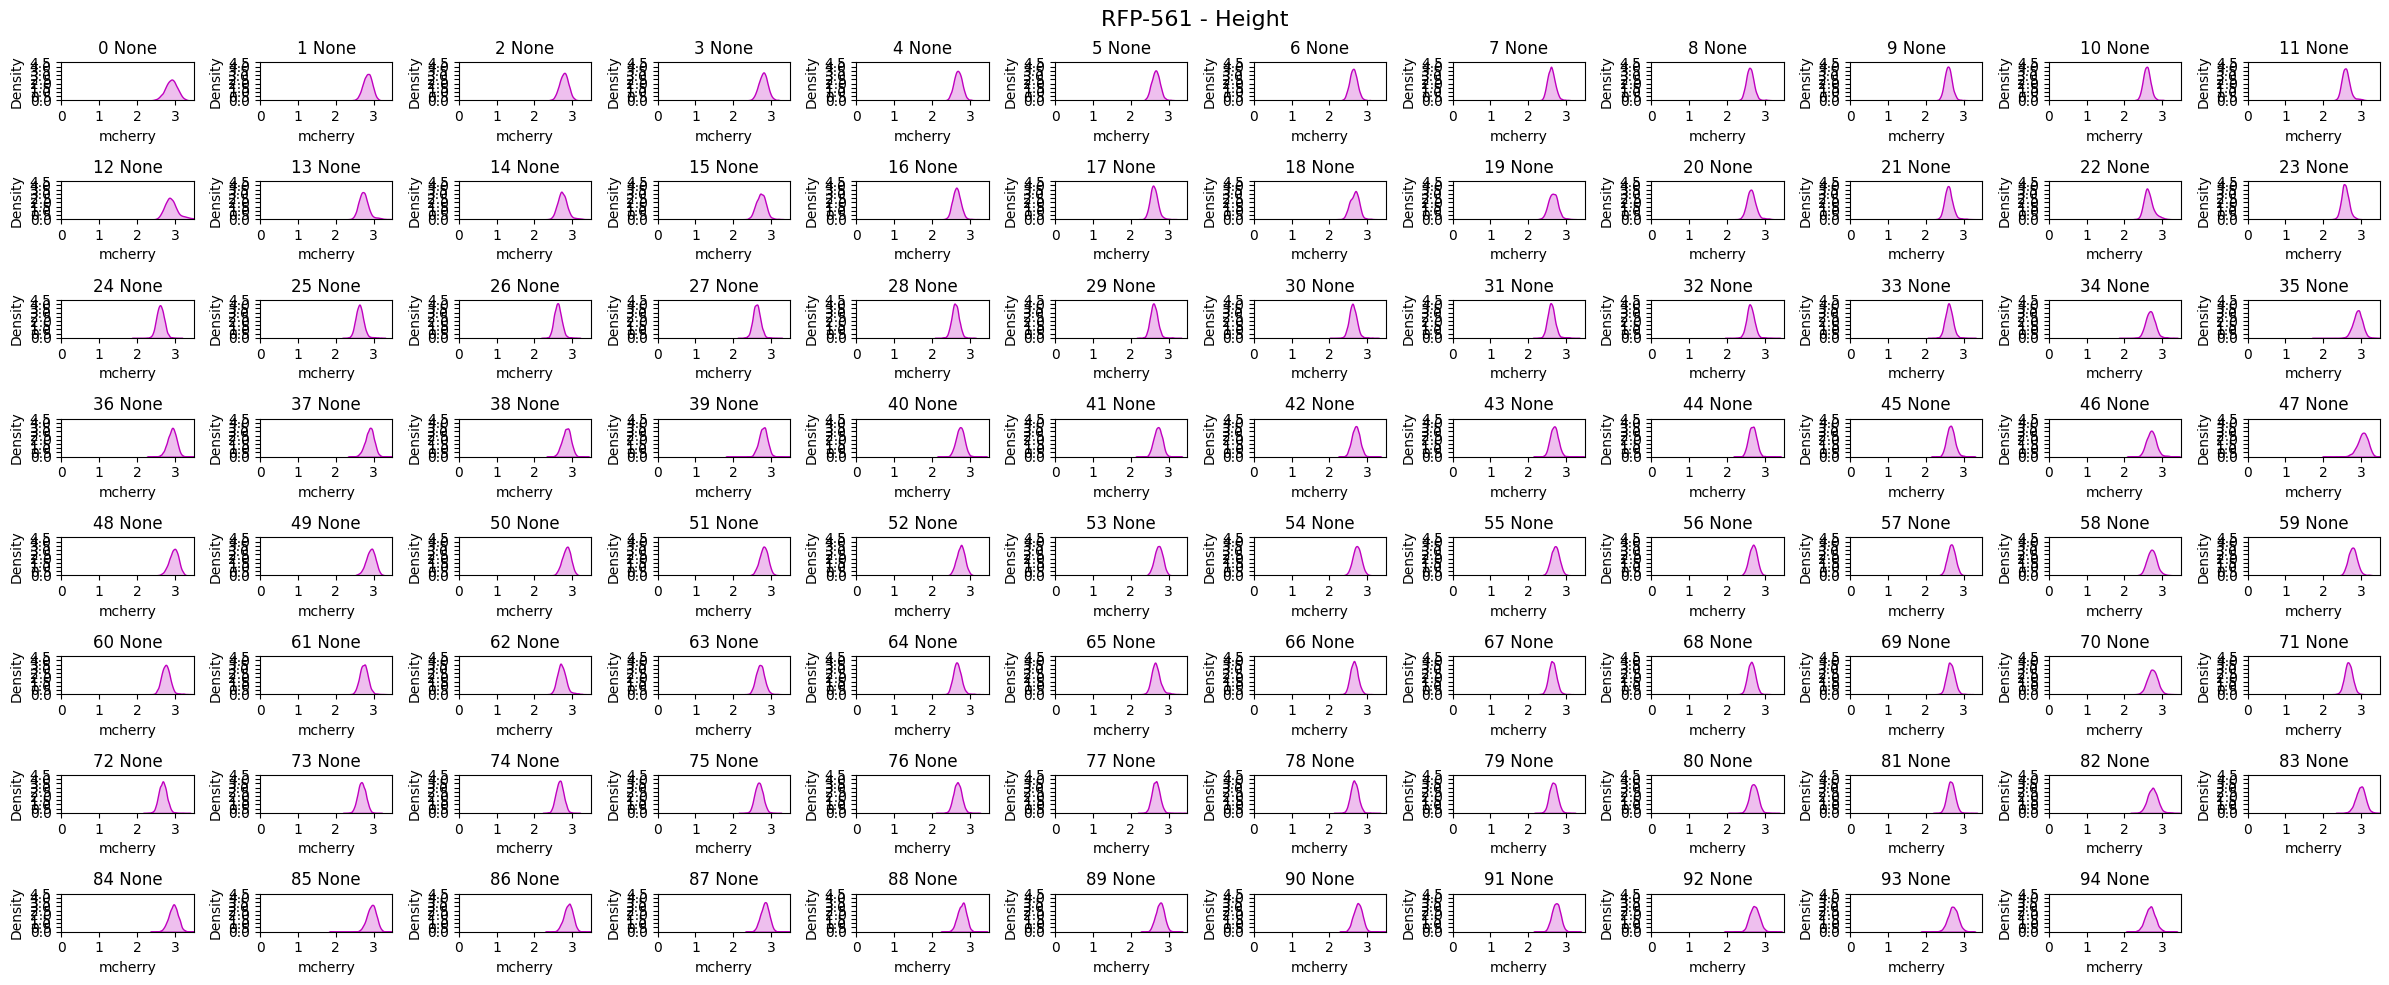

c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = 

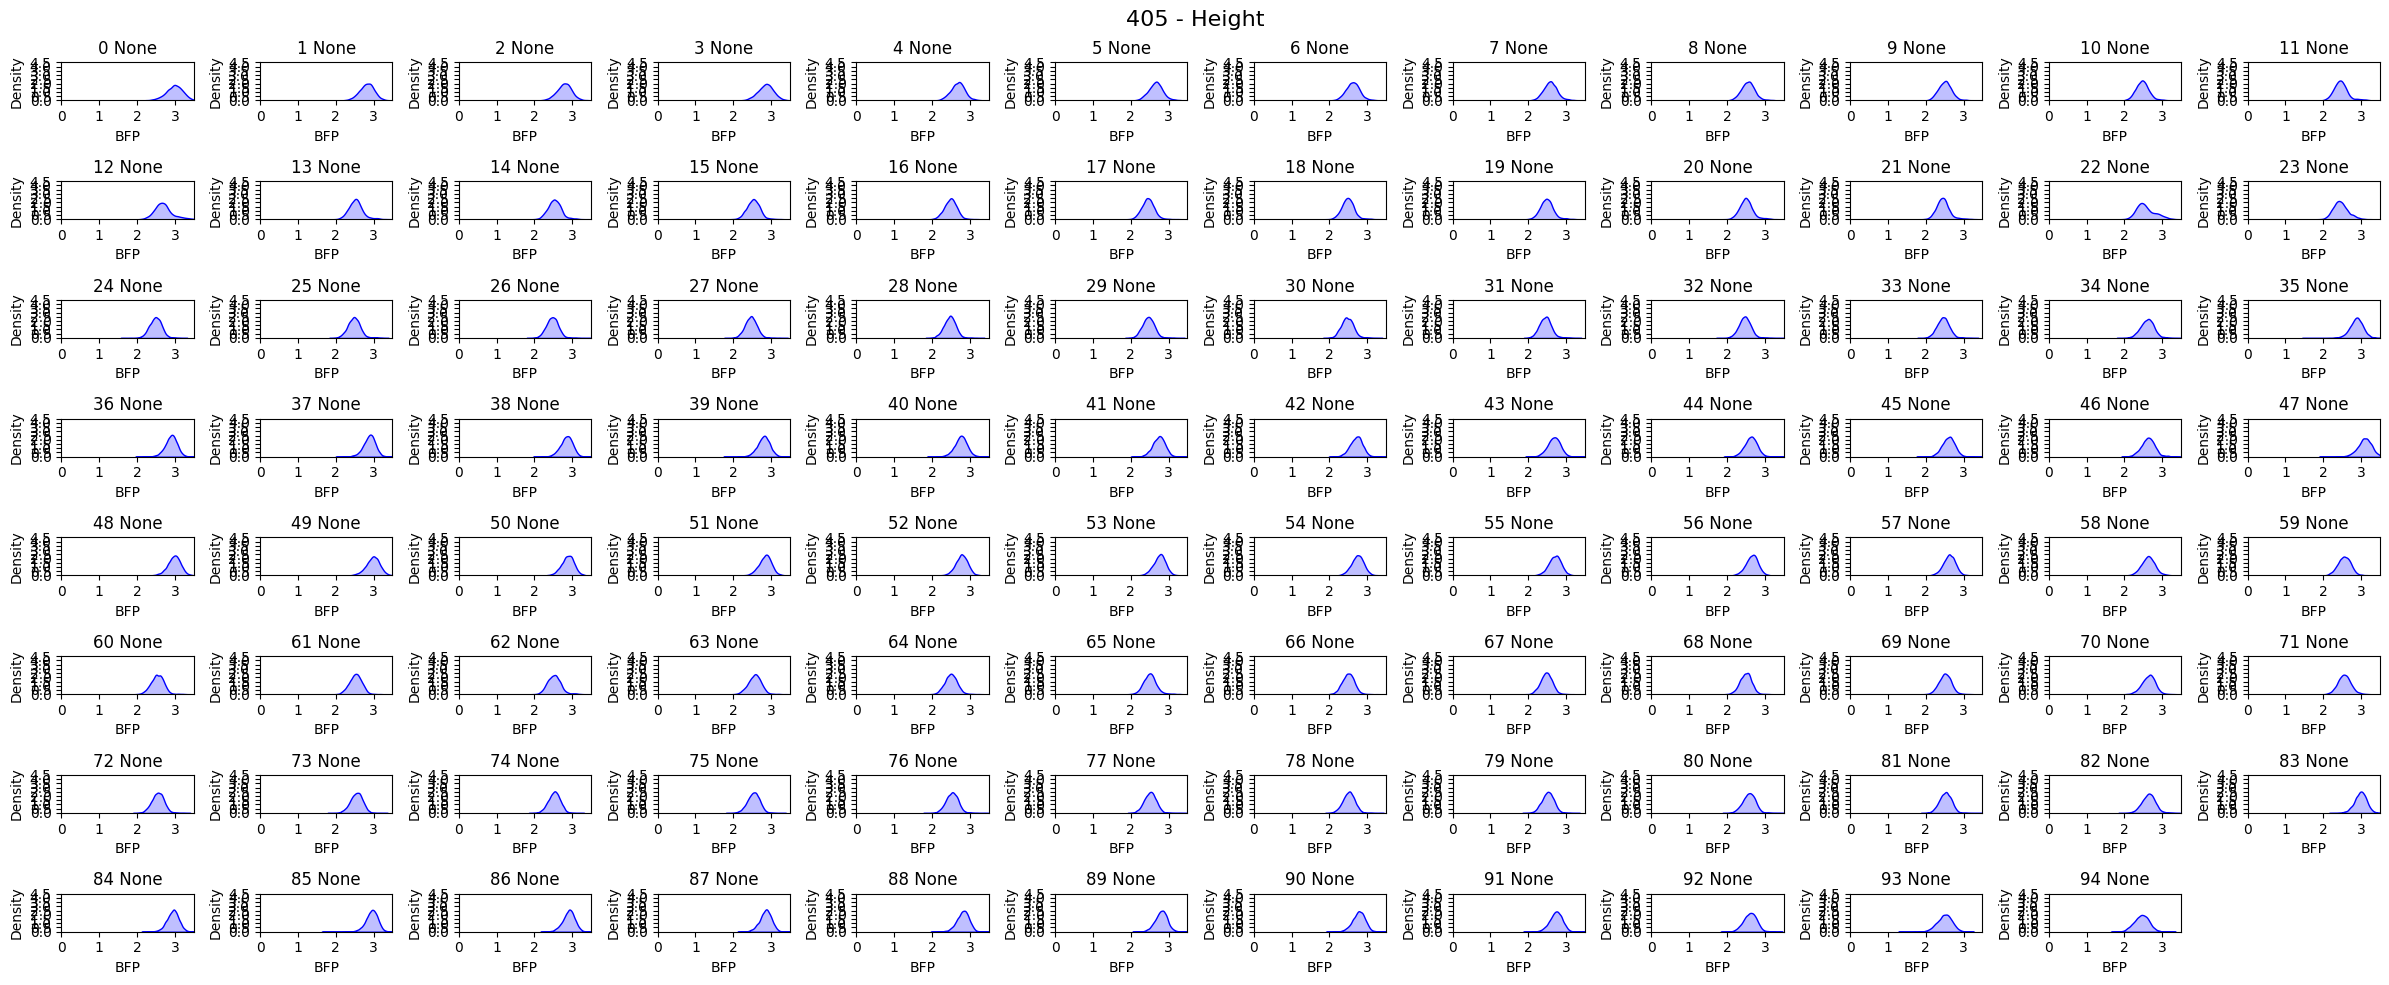

c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = 

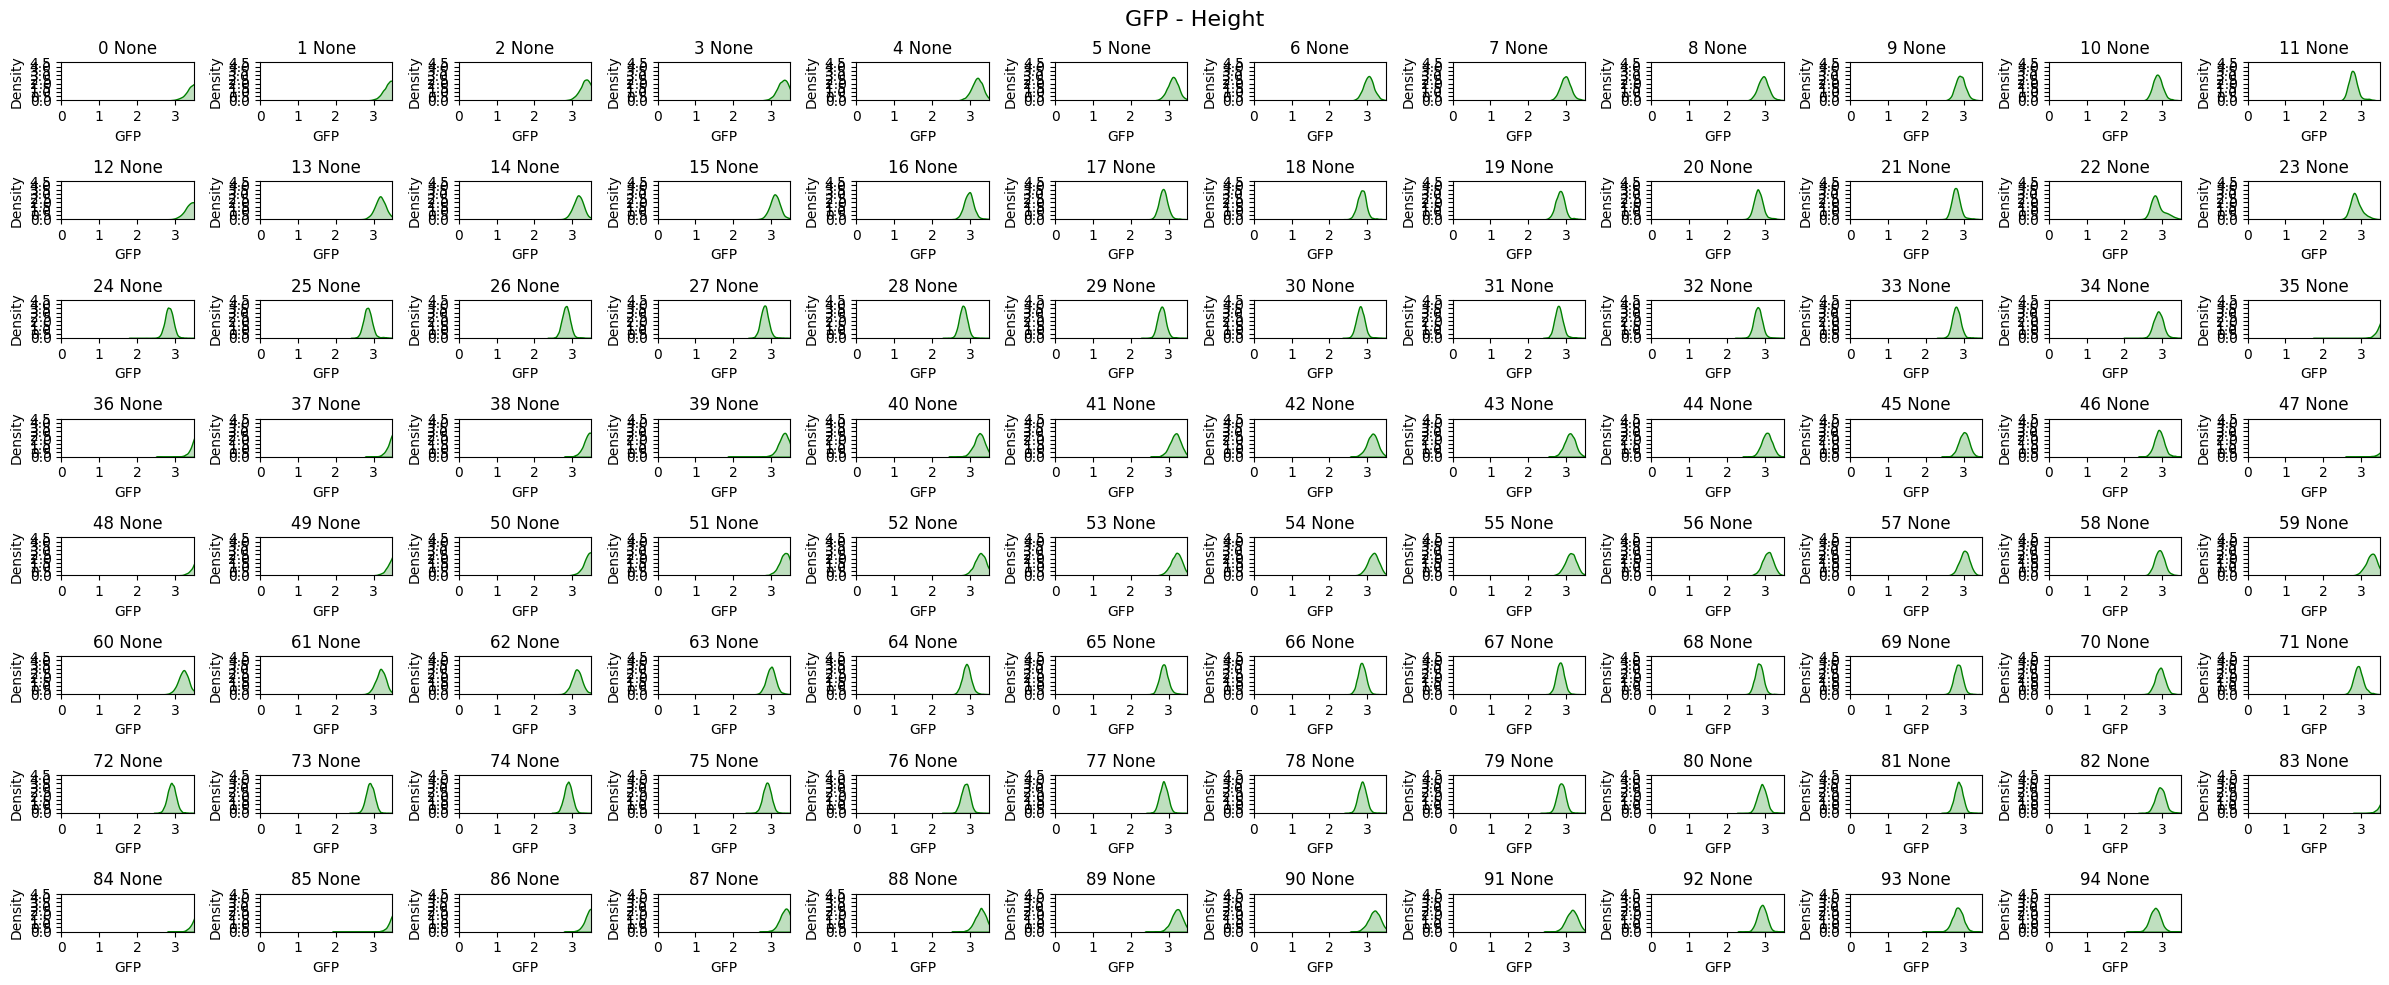

In [16]:


def extract_data(fcs_file, channel_names):
    """Extracts Channel 1 data from the given FCS file."""
          
    FSCLower = 4.0 
    FSCUpper = 4.8
    SSCLower = 2.5
    SSCUpper = 4.5

    sample = FCMeasurement(ID=fcs_file, datafile=Dirpath + '/' + fcs_file)
    temp_df = pd.DataFrame(data=sample.data)
    log_channels = list(temp_df.columns)  # name of the column headers 

    # Filtering and logging
    temp_df = temp_df[log_channels]
    temp_df = temp_df[temp_df[log_channels] > -np.Inf]
    temp_df = temp_df[temp_df[log_channels] < np.Inf]
    temp_df = np.log10(temp_df)
    temp_df = temp_df.dropna(axis=0, how='any')

    size_df = temp_df[FSCUpper > temp_df['FSC - Height']]
    size_df = size_df[size_df['FSC - Height'] > FSCLower]
    size_df = size_df[SSCLower < size_df['SSC - Height']]
    size_df = size_df[size_df['SSC - Height'] < SSCUpper]


    # Assuming 'Channel1' is named appropriately in your dataset
    channel1_data = size_df[channel_names]  # Update this to match your channel name
    return channel1_data

def plot_all_channel(all_files, channel_names, x_axis, title):    

    """Plots Channel 1 data from all FCS files in subplots."""
    num_files = len(all_files)
    cols = 12  # Number of columns in the subplot
    rows = 8  # Calculate number of rows needed

    fig, axs = plt.subplots(rows, cols, figsize=(24, 10))
    fig.suptitle(title, fontsize=16)
    axs = axs.flatten()  # Flatten the 2D array of axes for easy iteration

    for idx, fcs_file in enumerate(all_files):
        if '.fcs' in fcs_file:
            channel1_data = extract_data(fcs_file, channel_names)
            sns.kdeplot(channel1_data, ax=axs[idx], color=x_axis[0].lower(), fill=x_axis[0].lower())  # KDE plot
            well_id, sample_name = list(WellIDtoSampleName.items())[idx]
            axs[idx].set_title(f'{well_id} {sample_name}')  # Title based on file name
            axs[idx].set_xlabel(x_axis)
            axs[idx].set_ylabel('Density')
            axs[idx].set_xlim(0, 3.5)
            axs[idx].set_ylim(0, 2.5)
            axs[idx].set_xticks(np.arange(0, 4, 1))  
            axs[idx].set_yticks(np.arange(0, 5, 0.5)) 


    # Hide empty subplots if any
    for idx in range(num_files, rows * cols):
        fig.delaxes(axs[idx])
    


    plt.tight_layout()
    plt.show()

# Example usage:
plot_all_channel(All_Files, Channel1, 'mcherry', title= Channel1)
plot_all_channel(All_Files, Channel2, 'BFP', title=Channel2)
plot_all_channel(All_Files, Channel3, 'GFP', title=Channel3)




c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = 

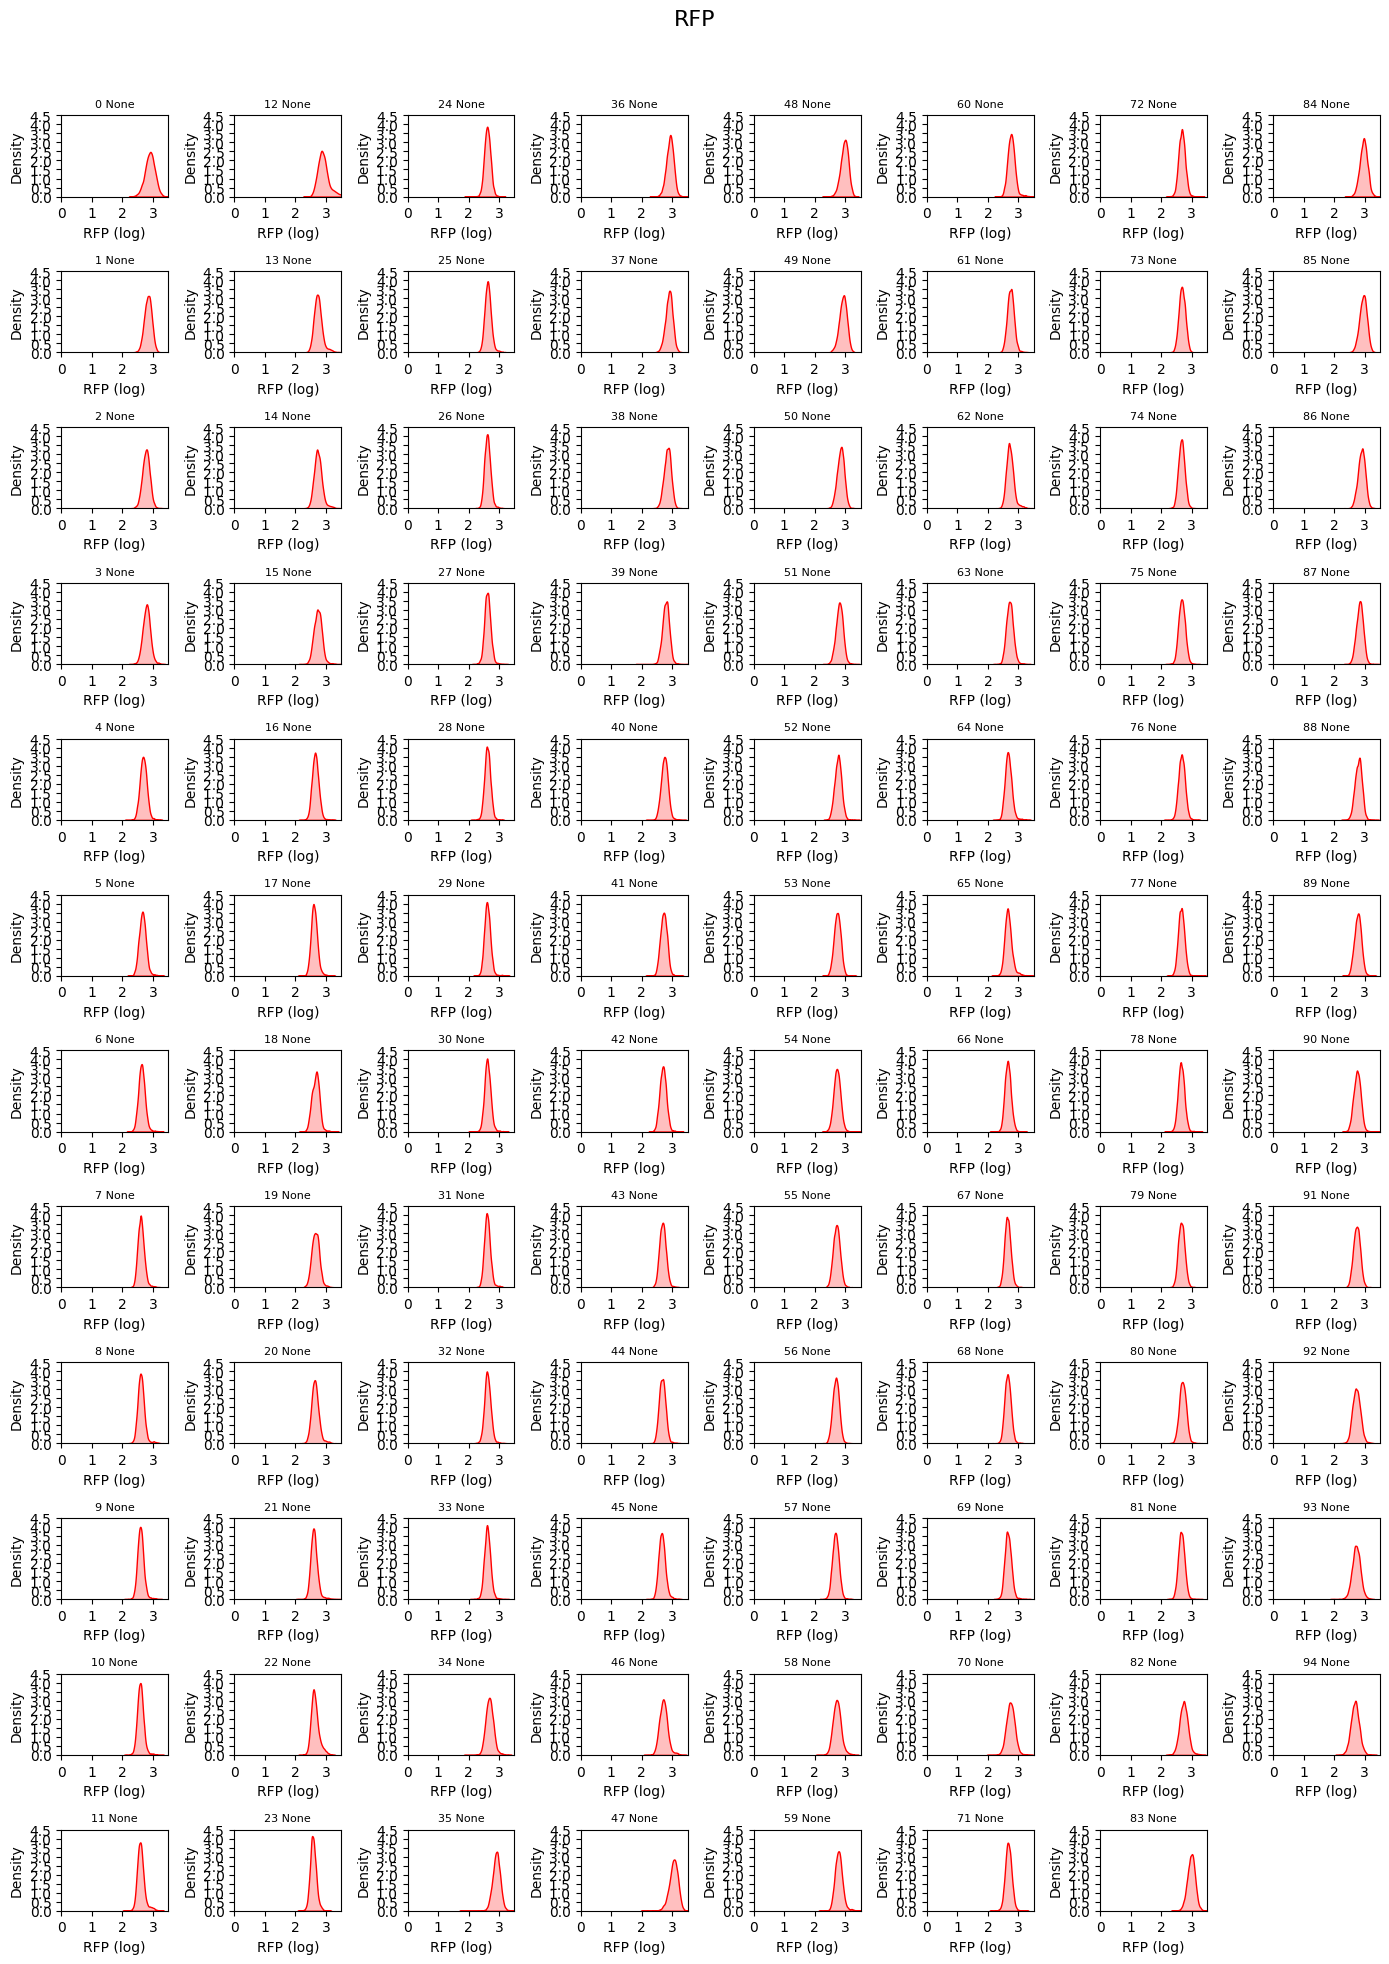

c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = 

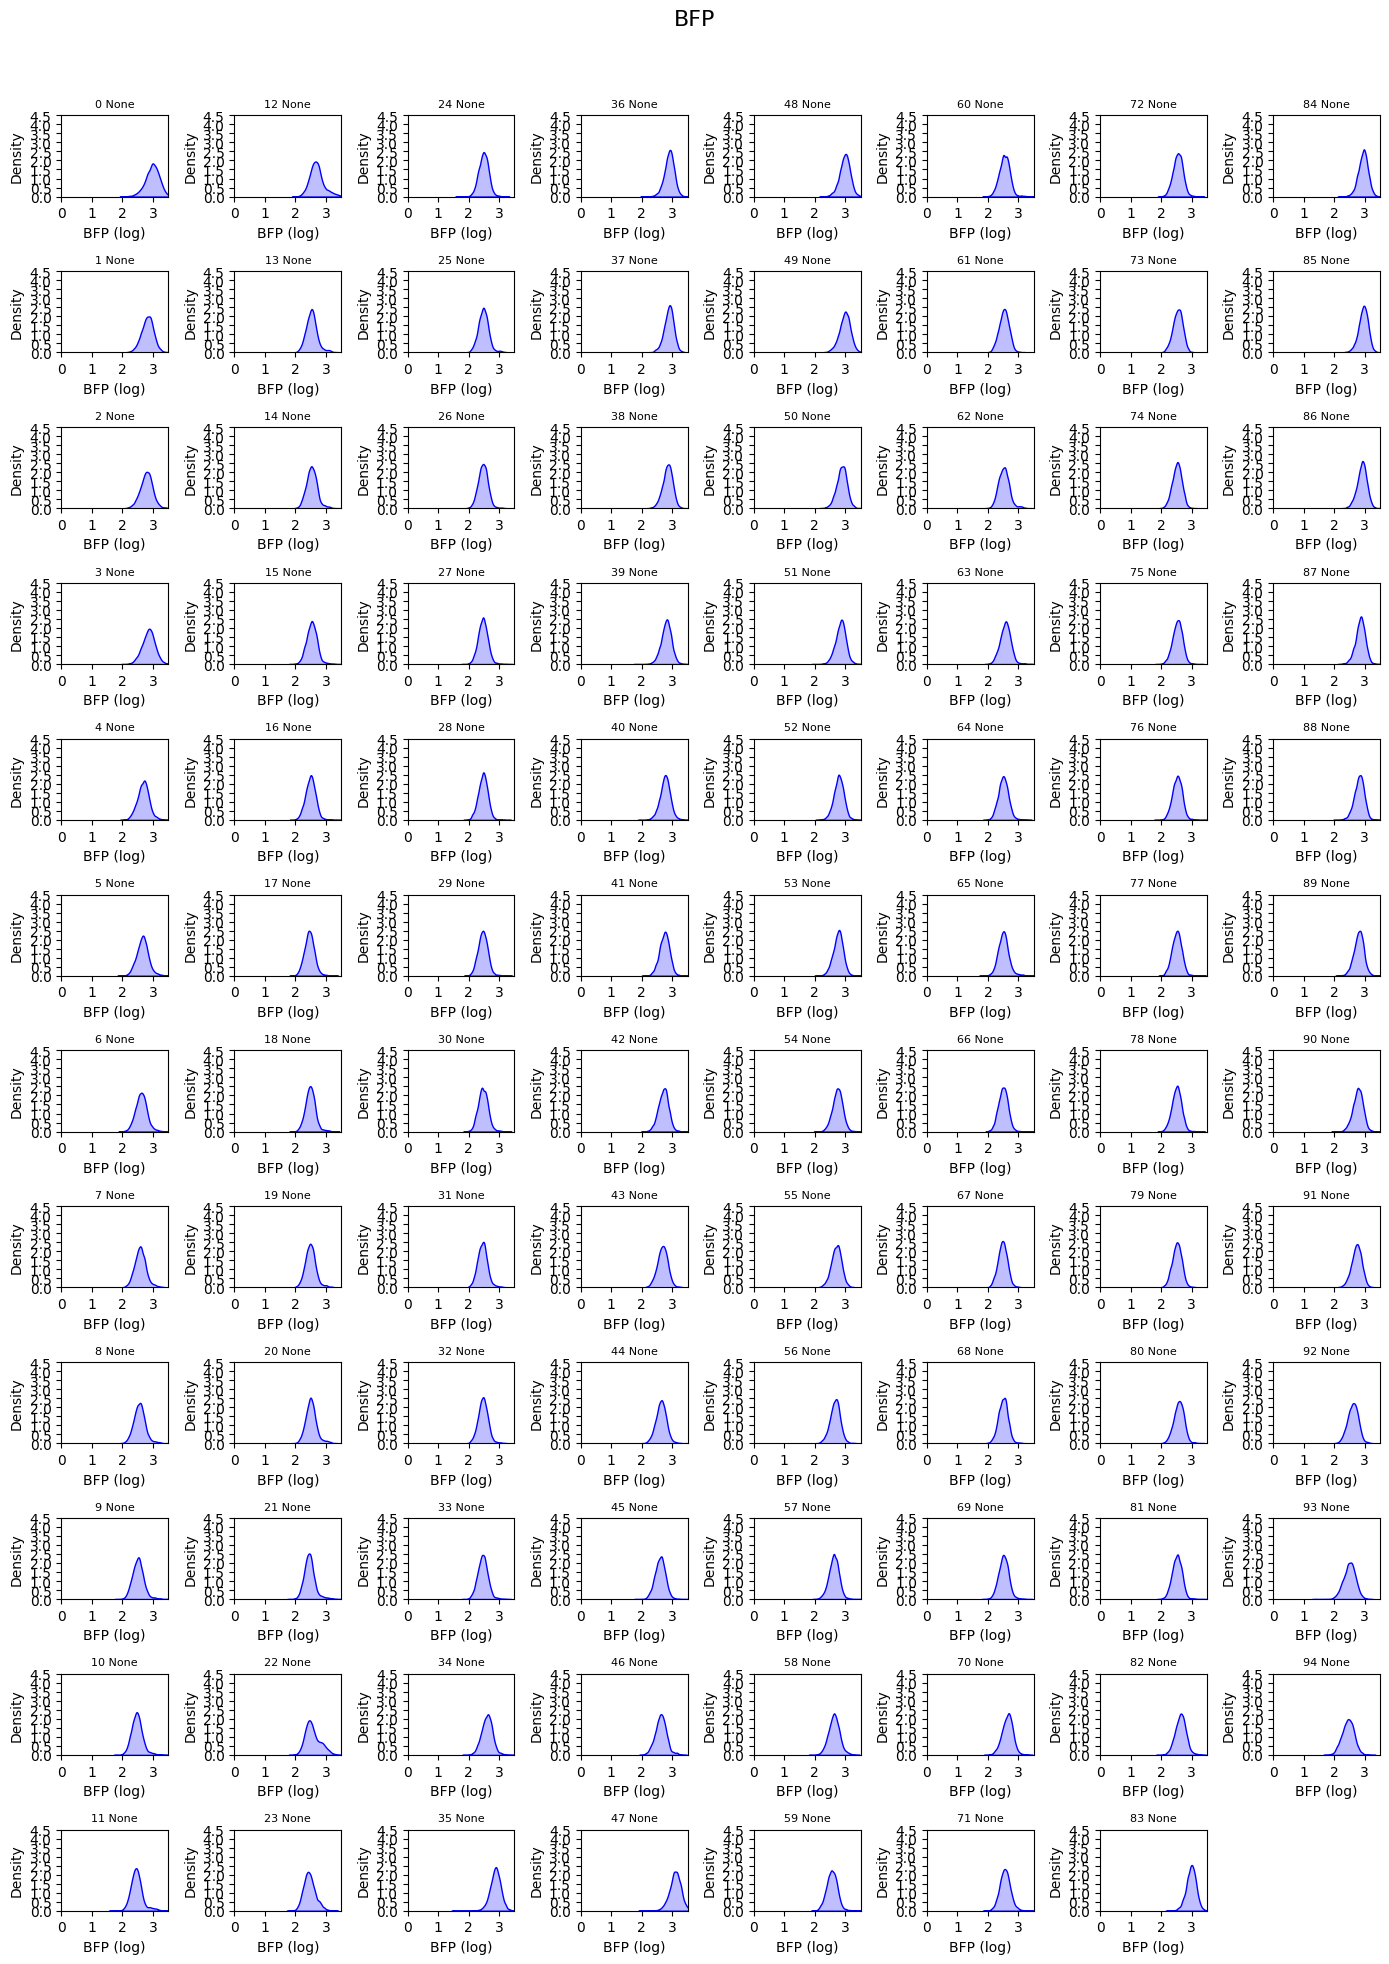

c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = 

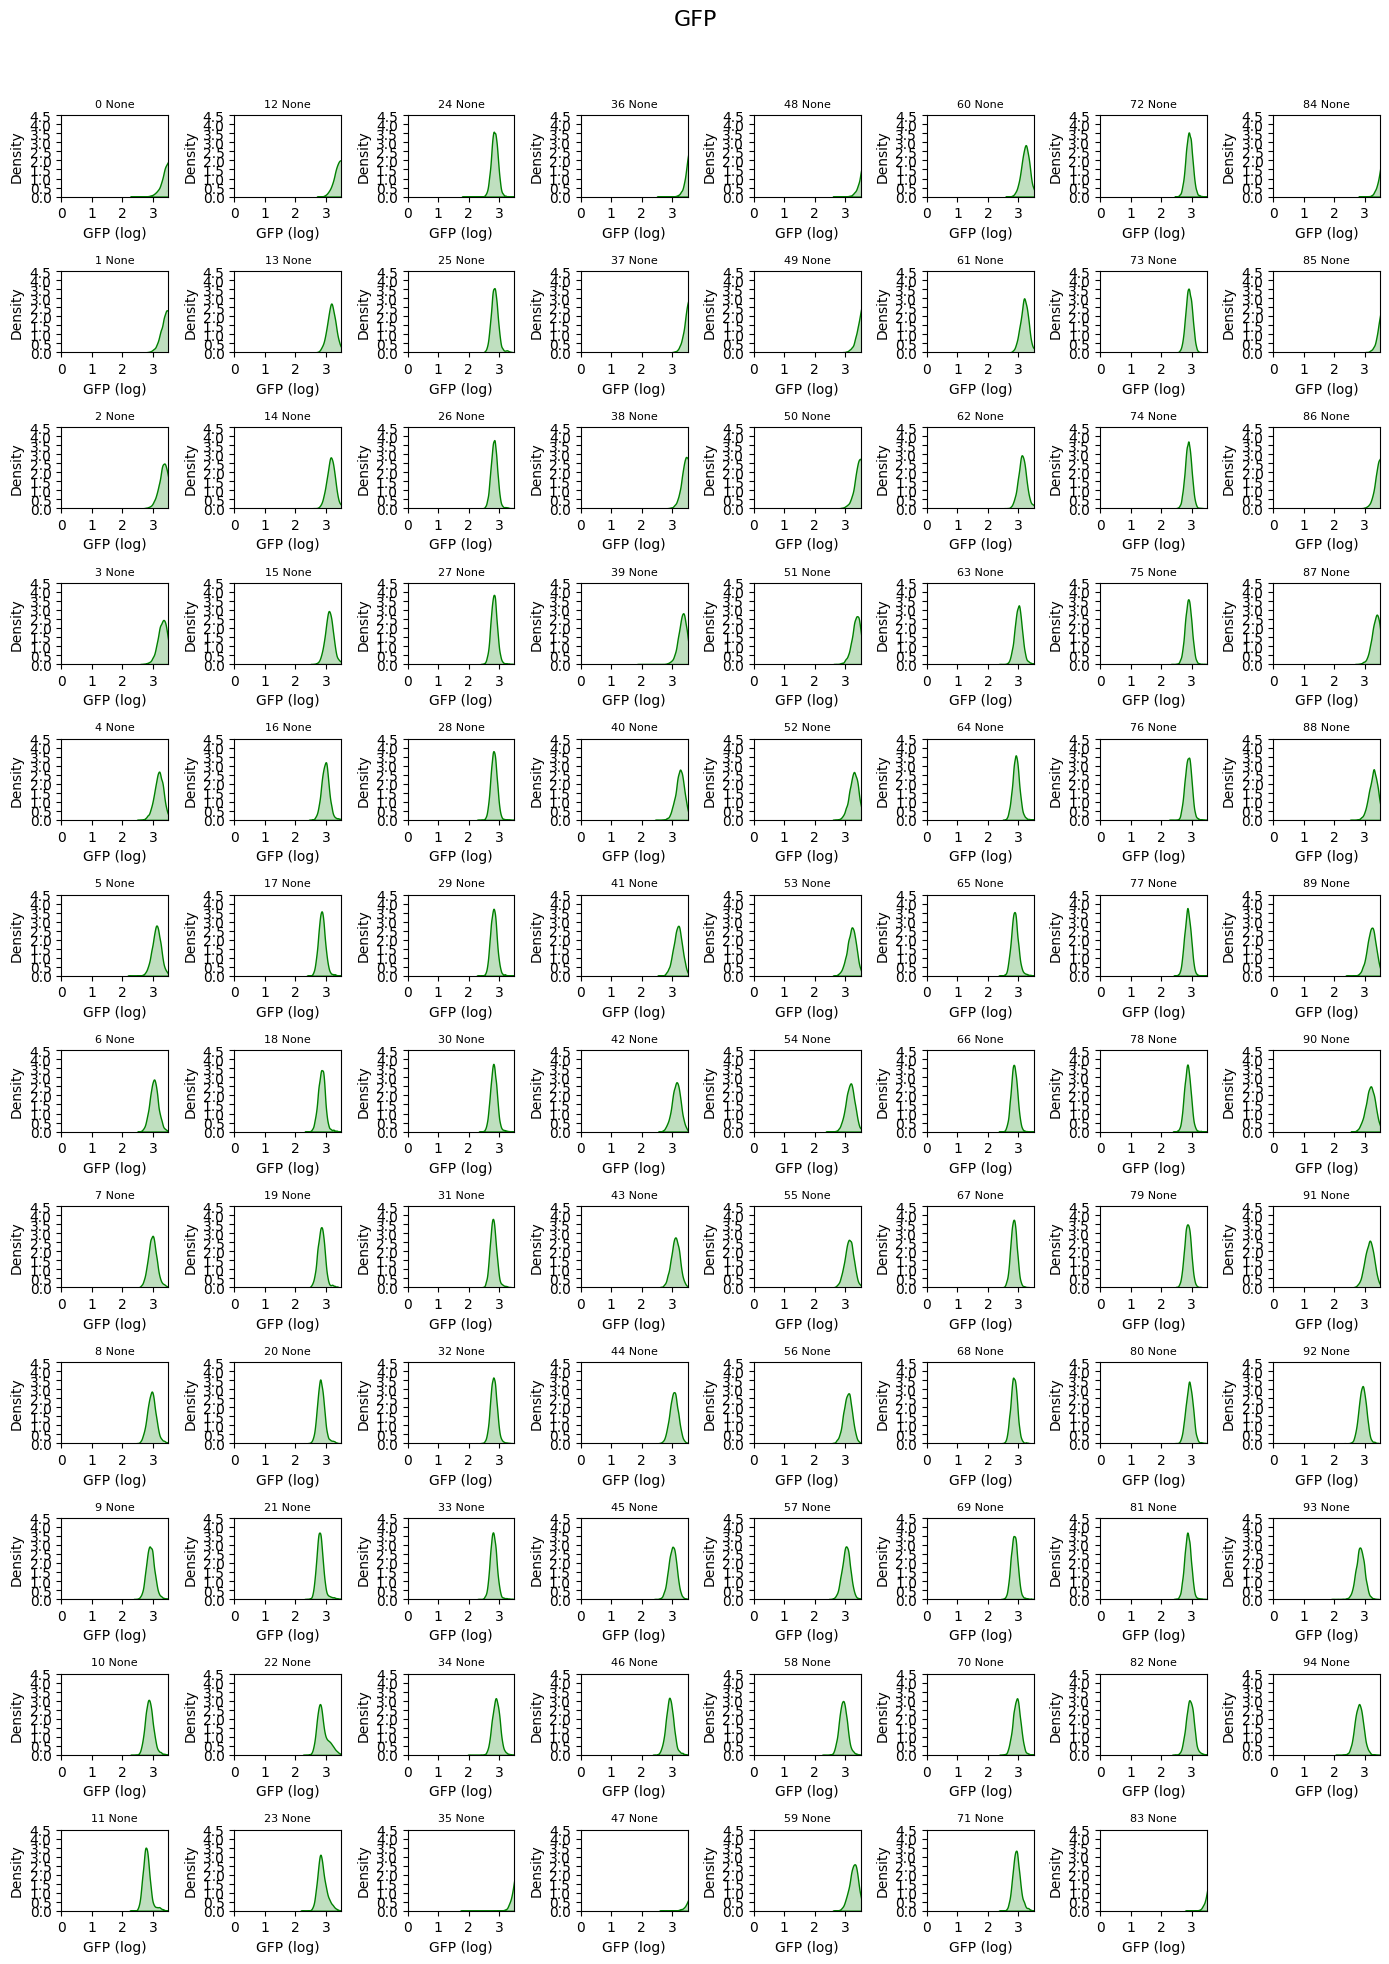

In [18]:
def plot_all_channel(all_files, channel_names, x_axis, title):    
    """Plots Channel data from all FCS files in subplots in a top-to-bottom, column-by-column order."""
    num_files = len(all_files)
    cols = 8  # Number of columns in the subplot
    rows = 12  # Calculate number of rows needed

    fig, axs = plt.subplots(rows, cols, figsize=(14, 20))
    fig.suptitle(title, fontsize=16)

    # Loop through each file and set the plot position in column-first order
    for idx, fcs_file in enumerate(all_files):
        if '.fcs' in fcs_file:
            # Determine row and column position based on top-to-bottom, column-by-column order
            row = idx % rows
            col = idx // rows

            # Get channel data and plot it
            channel1_data = extract_data(fcs_file, channel_names)
            sns.kdeplot(channel1_data, ax=axs[row, col], color=x_axis[0].lower(), fill=True)  # KDE plot
            
            # Set titles and labels for each subplot
            well_id, sample_name = list(WellIDtoSampleName.items())[idx]
            axs[row, col].set_title(f'{well_id} {sample_name}', fontsize=8)  
            axs[row, col].set_xlabel(x_axis)
            axs[row, col].set_ylabel('Density')
            axs[row, col].set_xlim(0, 3.5)
            axs[row, col].set_ylim(0, 2.5)
            axs[row, col].set_xticks(np.arange(0, 4, 1))  
            axs[row, col].set_yticks(np.arange(0, 5, 0.5)) 

    # Hide any unused subplots
    for idx in range(num_files, rows * cols):
        fig.delaxes(axs[idx % rows, idx // rows])

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to avoid overlap with title
    plt.show()

plot_all_channel(All_Files, Channel1, 'RFP (log)', title='RFP')
plot_all_channel(All_Files, Channel2, 'BFP (log)', title= 'BFP')
plot_all_channel(All_Files, Channel3, 'GFP (log)', title='GFP')


